# Global mCH & trinucleotide context (Fig 3A, S17, S18, S20)

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}scRNA/pseudobulk/L1/L1.hdf'`  ·  _scRNA/expr_
- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'mCH_distribution/multires/{ct}_hist.npy'`  ·  _other_
- `f'{indir}clustering/merged/group_meta.tsv'`  ·  _metadata_
- `f'{indir}merged_allc/cluster_donor.mcds'`  ·  _sc/pseudobulk mC (allc)_
- `'mCH_distribution/cluster420_chrom1k_mCH.hdf'`  ·  _other_
- `'mCH_distribution/cluster420_global_mCH.tsv.gz'`  ·  _table_
- `f'mCH_distribution/multires/{ct}_corr_{num2str(reslist[-1])}.npy'`  ·  _other_
- `f'mCH_distribution/multires/{ct}_corr_{num2str(res)}.npy'`  ·  _other_
- `f'mCH_distribution/multires/{ct.replace(" ","-").replace("/","_")}_corr_{num2str(res)}.npy'`  ·  _other_
- `f'mCH_distribution/multires/{ctname}_corr_{num2str(res)}.npy'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, spearmanr
from concurrent.futures import ProcessPoolExecutor, as_completed

import pysam
import seaborn as sns
import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, roc_auc_score

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'


In [4]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
# gene_meta = gene_meta.loc[gene_meta['chrom'].isin(chrom_sizes.index)]
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]
ens2gene = gene_meta.set_index('gene_id_idx')['gene_name'].to_dict()
gene2ens = gene_meta.set_index('gene_name')['gene_id_idx'].to_dict()


In [5]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
# annot_L1 = L1_meta.reset_index().set_index('L1_abbr')['L1'].to_dict()
# L1_annot['c35'] = 'Hema Bnaive'
# L1_annot['c7'] = 'Hema Bmem'
# L1_color['c35'] = L1_color['c7']
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [6]:
expr = pd.read_hdf(f'{indir}scRNA/pseudobulk/L1/L1.hdf', key='data')
expr = expr.rename(columns={'Neu Schw': 'Glia Schw'})  # RNA hdf keeps old name
# expr.columns = expr.columns.map(annot_L1)
expr = np.log1p(expr)

In [7]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
meta.columns

In [8]:
donor_palette = {xx:yy for xx,yy in zip(meta['Donor'].unique(), sns.color_palette('tab20', 20))}


In [9]:
# meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
meta['L2'] = meta['L1'].astype(str) + '-' + meta['L2_any'].astype(str)
L2_list = meta.groupby('L2')['mCHFrac'].median().sort_values().index


In [10]:
meta[['L1','L1_annot']] = meta[['L1','L1_annot']].astype(str)
meta['L1_annot'] = meta['L1'].map(L1_annot)
# meta.loc[(meta['L1']=='c7') & meta['L2_any'].isin(['c0','c10','c11']), 'L1_annot'] = 'Hema Bnaive'
# meta.loc[(meta['L1']=='c7') & ~meta['L2_any'].isin(['c0','c10','c11']), 'L1_annot'] = 'Hema Bmem'
# meta.loc[(meta['L1']=='c7') & meta['L2_any'].isin(['c0','c10','c11']), 'L1'] = 'c35'


In [11]:
donor_palette = {xx:yy for xx,yy in zip(meta['Donor'].unique(), sns.color_palette('tab20', 20))}
# colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color'].to_dict()
# colors['c35'] = colors['c7']
colors = L1_meta.set_index('L1_abbr')['color'].to_dict()
colors.update(L1_meta['color'].to_dict())  # also key by c-code so hue='L1' works too


In [12]:
L1_list = meta.groupby('L1_annot')['mCHFrac'].median().sort_values().index

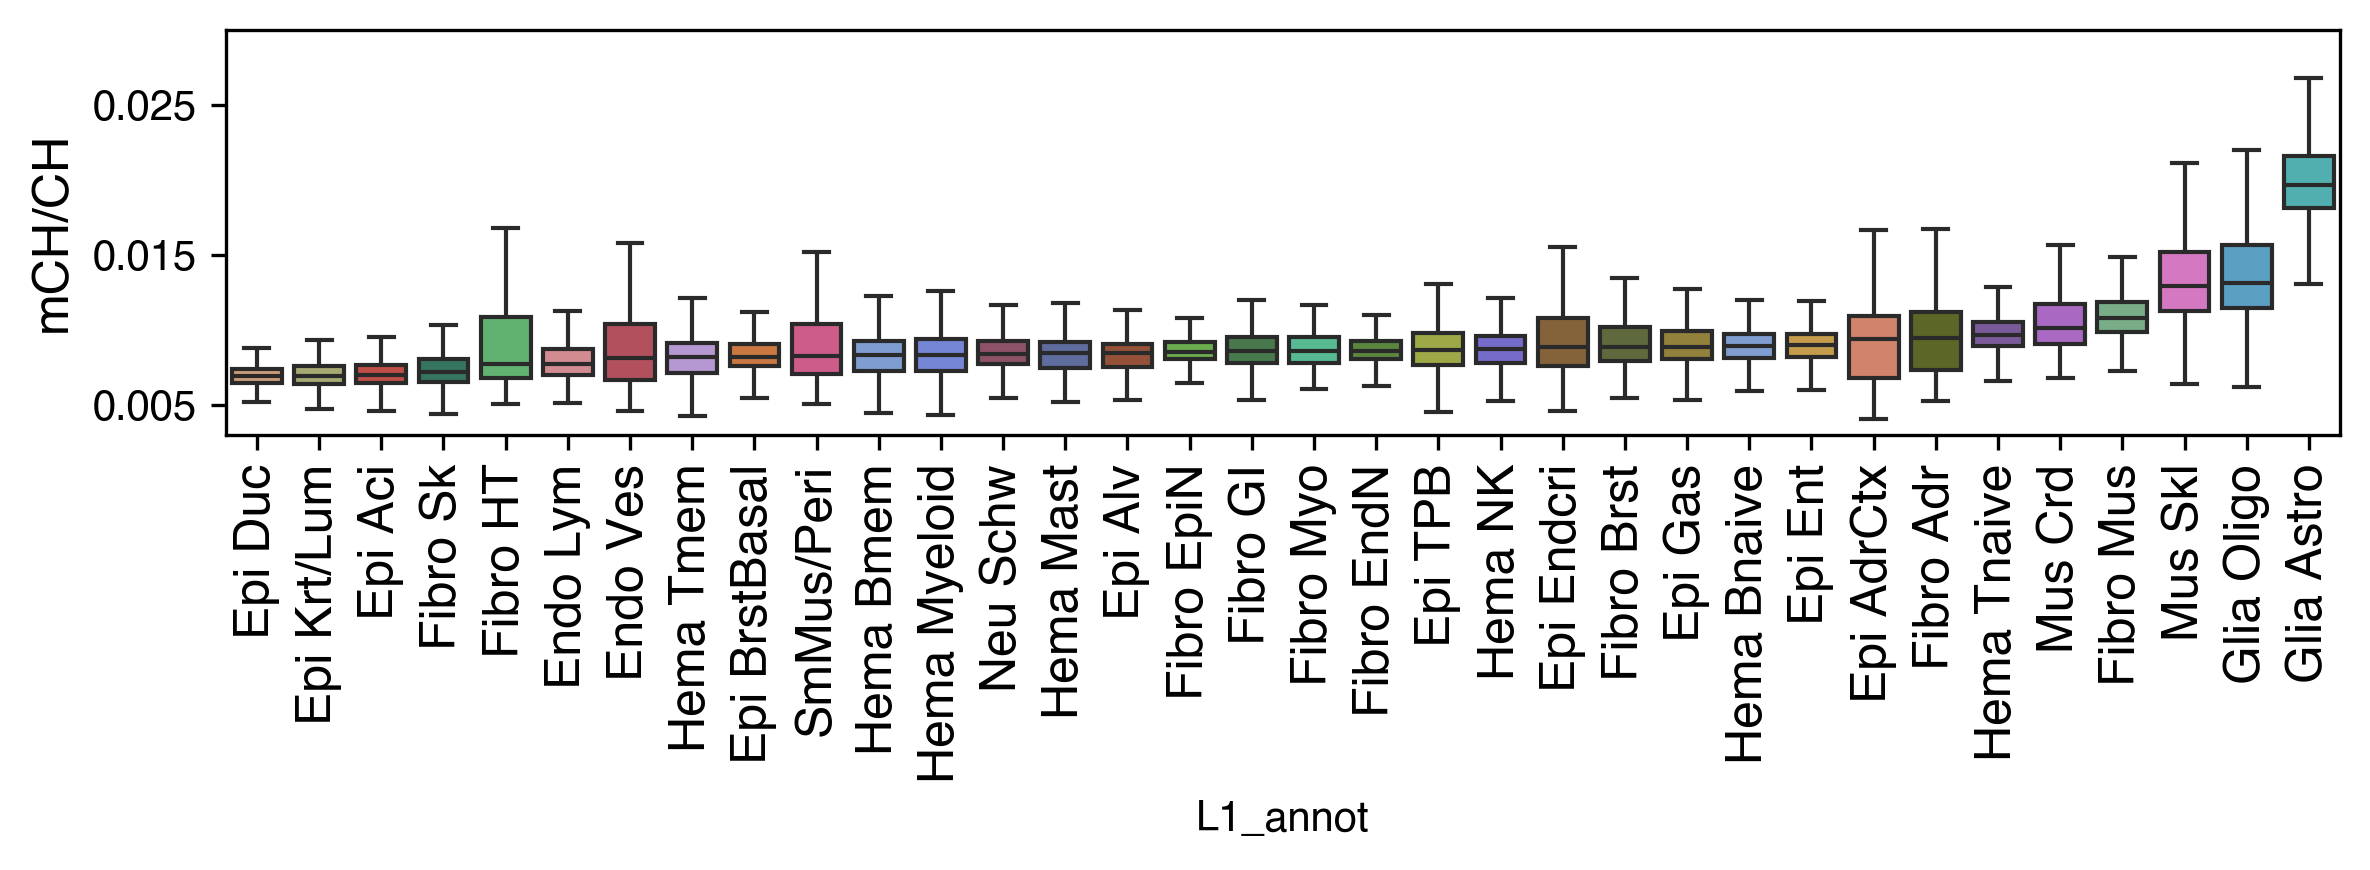

In [13]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
sns.boxplot(data=meta.loc[~meta['L1'].isin(['c10','c16'])], x='L1_annot', y='mCHFrac', hue='L1', ax=ax, 
            palette=colors, order=L1_list[:-2], showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=90)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_ylabel('mCH/CH', fontsize=12)
ax.get_legend().set_visible(False)
ax.set_yticks(np.arange(0.005, 0.03, 0.01))
ax.set_ylim([0.003, 0.03])
fig.tight_layout()
fig.savefig('mCH_distribution/L1_cellglobalCH_box.pdf', transparent=True)


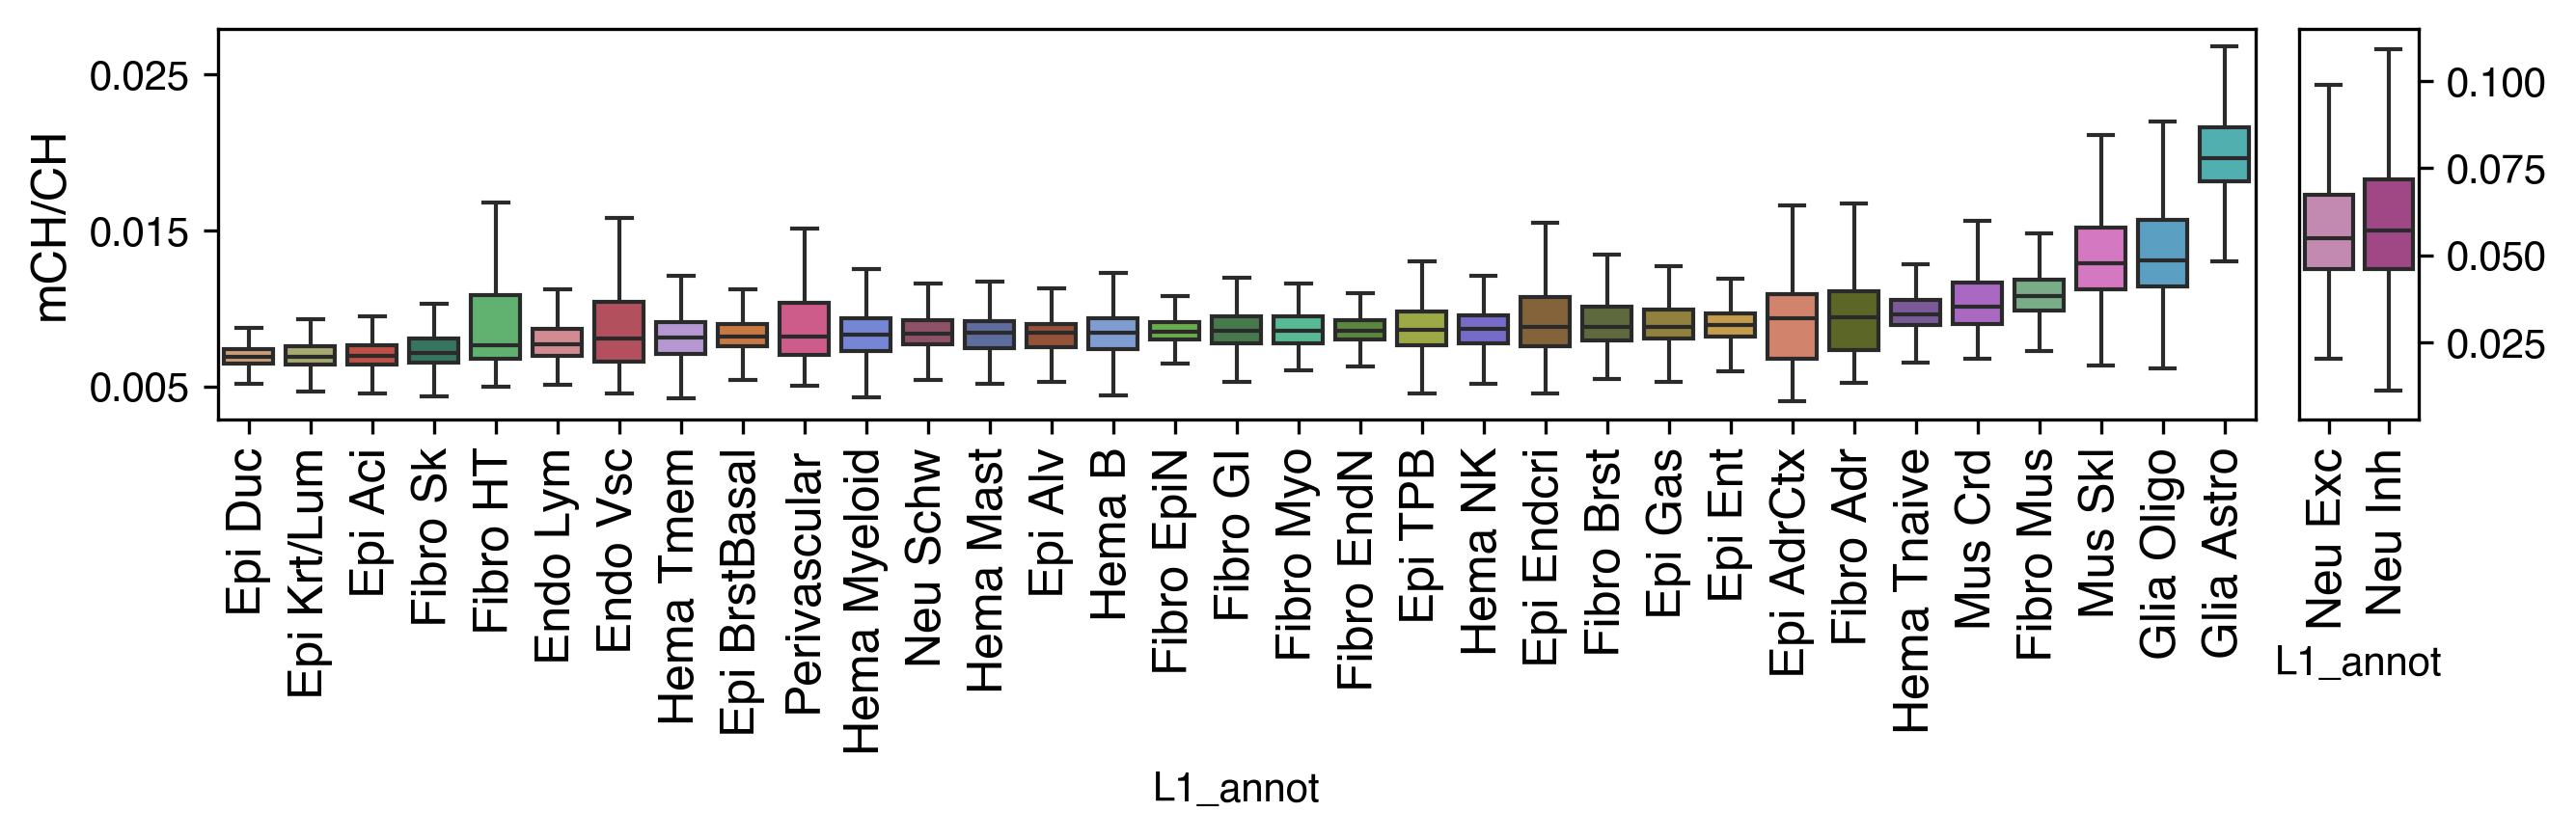

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [17,1]}, dpi=300)
selneu = meta['L1'].isin(['c10','c16'])
ax = axes[0]
sns.boxplot(data=meta.loc[~selneu], x='L1_annot', y='mCHFrac', hue='L1_annot', ax=ax, 
            palette=colors, order=L1_list[:-2], showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=90)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_ylabel('mCH/CH', fontsize=12)
# ax.get_legend().set_visible(False)
ax.set_yticks(np.arange(0.005, 0.03, 0.01))
# ax.set_ylim([0.003, 0.03])

ax = axes[1]
sns.boxplot(data=meta.loc[selneu], x='L1_annot', y='mCHFrac', hue='L1_annot', ax=ax, 
            palette=colors, order=L1_list[-2:], showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=90)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_ylabel('')
# ax.get_legend().set_visible(False)
ax.set_yticks(np.arange(0, 0.11, 0.025))
ax.set_ylim([0.003, 0.115])
ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
fig.tight_layout()
fig.savefig('mCH_distribution/L1_cellglobalCH_box.pdf', transparent=True)


In [15]:
mch = meta.groupby('L1_annot')['mCHFrac'].median().sort_values()

In [16]:
from scipy.stats import pearsonr, spearmanr


In [17]:
# tmp = expr.drop(['Neu Exc', 'Neu Inh'], axis=1)
tmp = expr.copy()
yy = mch.loc[tmp.columns].values
scorr = pd.Series([spearmanr(xx,yy)[0] for xx in tmp.values], 
                  index=tmp.index.map(ens2gene)).dropna()


In [18]:
tmp = expr.drop(['Neu Exc', 'Neu Inh'], axis=1)
pcorr = pairwise_distances(mch.loc[tmp.columns].values[None, :], tmp, metric='correlation')
pcorr = pd.Series(1-pcorr[0], index=tmp.index.map(ens2gene)).dropna()


In [19]:
tmp = expr.T
tmp.columns = tmp.columns.map(ens2gene)
tmp['mCH'] = mch.copy()
tmp['color'] = colors.copy()


In [20]:
turnover_rate = {
    "c33": 0.10,  # Endo Lymphatic
    "c3": 0.05,   # Endo Vascular
    "c22": 0.2,   # Epi Acinar
    "c9": 1.0,    # Epi Adrenal
    "c20": 0.3,   # Epi Alveolar
    "c25": 0.5,   # Epi Breast Basal
    "c30": 0.5,   # Epi Ductal
    "c13": 0.2,   # Epi Endocrine
    "c8": 30.0,   # Epi Enteric
    "c4": 12.0,   # Epi Gastric
    "c18": 18.0,  # Epi Keratinous/Luminal
    "c2": 50.0,   # Epi Trophoblast
    "c29": 0.2,   # Fibro Adrenal
    "c17": 0.2,   # Fibro Breast
    "c19": 0.1,   # Fibro Endoneurial
    "c28": 0.1,   # Fibro Epineurial
    "c6": 0.2,    # Fibro Gastrointestinal
    "c11": 0.1,   # Fibro Heart
    "c32": 0.2,   # Fibro Muscular
    "c34": 4.0,   # Myofibroblast
    "c23": 0.5,   # Fibro Skin
    "c31": 0.05,  # Glia Astrocyte
    "c14": 0.10,  # Glia Oligodendrocyte
    "c7": 4.0,    # Hema B
    "c24": 1.0,   # Hema Mast
    "c0": 50.0,   # Hema Myeloid
    "c27": 12.0,  # Hema NK
    "c1": 1.0,    # Hema Tmem
    "c15": 0.2,   # Hema Tnaive
    "c26": 0.01,  # Mus Cardiac
    "c5": 0.02,   # Mus Skeletal
    "c10": 0.0,   # Neu Excitatory
    "c16": 0.0,   # Neu Inhibitory
    "c21": 0.05,  # Glia Schwann
    "c12": 0.05,  # Perivascular
}
turnover_rate = pd.Series(turnover_rate)
turnover_rate.index = turnover_rate.index.map(L1_annot)
tmp['turnover_rate'] = np.log1p(turnover_rate)


In [21]:
L1_list = L1_list.str.replace(' ', '-').str.replace('/', '_')

In [22]:
context_list = pd.Index([f'C{xx}{yy}' for xx in 'ACGT' for yy in 'ACGT'])

In [23]:
selch = np.array([xx[1]!='G' for xx in context_list])

In [24]:
result = {ct:np.load(f'mCH_distribution/multires/{ct}_hist.npy') for ct in L1_list}
data = pd.DataFrame([result[ct][0][selch].sum(axis=0) for ct in L1_list], index=L1_list)
# data = (data.T / data.sum(axis=1)) * 1e6


In [25]:
tmp = (data.T / data.sum(axis=1)).iloc[:100] * 1e6

In [26]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# group_meta = group_meta[['L2_any', 'L1', 'count']]
group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ','-').str.replace('/','_')
annot2L1 = group_meta[['L1','L1_annot']].set_index('L1_annot')['L1'].to_dict()
L1annot = group_meta[['L1','L1_annot']].set_index('L1')['L1_annot'].to_dict()


In [27]:
from ALLCools.mcds import MCDS

mcds = MCDS.open(f'{indir}merged_allc/cluster_donor.mcds', var_dim='chrom1k')
mcds

In [28]:
mcds = mcds.assign_coords(L2_any=('cell', group_meta.loc[mcds.get_index('cell'), 'L2_any']))
mcds = mcds.groupby('L2_any').sum()


In [29]:
mcds = mcds.sel({'mc_type':['CAN','CCN','CTN']}).sum(dim='mc_type')
mcds = MCDS(mcds, obs_dim='L2_any', var_dim='chrom1k')


In [30]:
cov = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='L2_any').squeeze().to_pandas()


In [31]:
cov.to_hdf('mCH_distribution/chrom1k_L2any_cov.hdf', key='data')


In [32]:
mcds = mcds.sel({'chrom1k':cov.index[cov>100]})

black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)

In [33]:
global_cg = mcds['chrom1k_da'].sum(dim='chrom1k').to_pandas()
global_cg = global_cg['mc'] / global_cg['cov']

In [34]:
global_cg.to_csv('mCH_distribution/cluster420_global_mCH.tsv.gz', sep='\t', header=None)


In [35]:
mcds.add_mc_frac(normalize_per_cell=False)
data = mcds['chrom1k_da_frac'].to_pandas()


In [36]:
data.to_hdf('mCH_distribution/cluster420_chrom1k_mCH.hdf', key='data')

In [37]:
data = pd.read_hdf('mCH_distribution/cluster420_chrom1k_mCH.hdf', key='data')
global_cg = pd.read_csv('mCH_distribution/cluster420_global_mCH.tsv.gz', sep='\t', header=None, index_col=0)[1]


In [38]:
nbins = 100
result = np.zeros((data.shape[0], nbins))
for i,xx in enumerate(data.values):
    result[i] = np.histogram(xx, bins=nbins, range=(0,0.1))[0]
    
result = pd.DataFrame(result, index=data.index)


In [39]:
L2meta = pd.DataFrame(index=result.index)
L2meta['L1_annot'] = result.index.str.split('-').str[0].map(L1annot)
L2meta['globalCH'] = global_cg.copy()


In [40]:
selc = []
border = [-0.5]
yticks = []
yticklabels = []
for xx in L2meta[['L1_annot', 'globalCH']].groupby('L1_annot')['globalCH'].mean().sort_values().index:
    tmp = L2meta.loc[L2meta['L1_annot']==xx, 'globalCH'].sort_values().index
    selc.append(tmp)
    yticks.append(border[-1]+len(tmp)/2)
    border.append(border[-1]+len(tmp))
    yticklabels.append(xx)
    
selc = np.concatenate(selc)


In [41]:
# result = result.loc[data.mean(axis=1).sort_values().index]
# result = result.loc[global_cg.sort_values().index]
result = result.loc[selc]

In [42]:
colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color']
row_colors = result.index.str.split('-').str[0].map(colors)
cg = sns.clustermap(np.log2(result+1), col_cluster=False, row_cluster=False, 
                    vmin=10, vmax=18, cmap='vlag', figsize=(5,12), 
                    row_colors=row_colors)
xticks = np.arange(0,101,20)
xticklabels = np.around(xticks/1000, decimals=2).astype(str)
cg.ax_heatmap.axes.set_xticks(xticks, labels=xticklabels)
cg.ax_heatmap.axes.set_yticks(yticks, labels=yticklabels)
for xx in colors.index:
    cg.ax_col_dendrogram.bar(0, 0, color=colors.loc[xx],
                            label=L1annot[xx], linewidth=0)
cg.ax_col_dendrogram.legend(loc="center", ncol=5, framealpha=0)
# cg.ax_heatmap.vlines(x=70, colors='k', ymin=-0.5, ymax=result.shape[0]-0.5, linewidths=0.5)
for xx in border:
    cg.ax_heatmap.hlines(y=xx, colors='k', xmin=-0.5, xmax=result.shape[1]-0.5, linewidths=0.5)


In [43]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [44]:
rm_list = []
for bed_path in [f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed', f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz']:
    bed = pd.read_csv(bed_path, sep='\t', header=None, index_col=None)
    bed = {chrom:bed.loc[bed[0]==chrom, [1,2]].values for chrom in chrom_sizes.index}
    rm_list.append(bed)
    

In [45]:
# L1_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L1/CHN/c*.allc.tsv.gz')])
# # L1_list = L1_list[L1_list!='Hema-B']
# L2_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L2any/*.CGN-Merge.allc.tsv.gz')])
# print(len(L1_list), len(L2_list))
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)


In [46]:
nbins = 1000
reslist = pd.Index([10, 50, 100, 500, 1000, 5000, 10000, 50000])
context_list = pd.Index([f'C{xx}{yy}' for xx in 'ACGT' for yy in 'ACGT'])


In [47]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str


In [48]:
def multires_ch(ct, allc_path):
    bincount = np.zeros(len(reslist))
    sum_x2, sum_x = np.zeros((2, len(reslist), len(context_list)))
    sum_xy = np.zeros((len(reslist), len(context_list), len(context_list)))
    result = np.zeros((len(reslist), len(context_list), nbins))
    for chrom,start,end in zip(chunks['chrom'].values, chunks['start'].values, chunks['end'].values):
        npos = (end - start) // reslist[-1] * reslist[-1]
        data = []
        # with gzip.open(allc_path, 'rt') as allc_lines:
        with pysam.TabixFile(allc_path) as allc:
            allc_lines = allc.fetch(chrom, start, end)
            for line in allc_lines:
                _, pos, _, context, mc, cov, *_ = line.split("\t")
                data.append([pos, context, mc, cov])

        data = pd.DataFrame(data, columns=['pos', 'context', 'mc', 'cov'])
        data[['pos', 'mc', 'cov']] = data[['pos', 'mc', 'cov']].astype(int)
        posfilter = np.ones(data.shape[0]).astype(bool)
        for bed in rm_list:
            bedtmp = bed[chrom][np.logical_and(bed[chrom][:,0]<end, bed[chrom][:,1]>start)]
            for xx,yy in bedtmp:
                posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False

        data = data.loc[posfilter & ((data['pos']-start) < npos)]
        data = data.groupby('context')
        ratio_multires = {res:[] for res in reslist}
        for k,context in enumerate(context_list):
            if not context in data.groups.keys():
                continue
            df = data.get_group(context)
            data_mc = csr_matrix((df['mc'], (np.zeros(df.shape[0]), df['pos']-start-1)), shape=[1, npos])
            data_cov = csr_matrix((df['cov'], (np.zeros(df.shape[0]), df['pos']-start-1)), shape=[1, npos])
            for i,res in enumerate(reslist):
                tmp = data_mc.reshape((-1, res)).sum(axis=1).A1 / data_cov.reshape((-1, res)).sum(axis=1).A1
                ratio_multires[res].append(tmp)
                tmp = tmp[~np.isnan(tmp)]
                tmp = np.histogram(tmp, bins=nbins, range=(0,1))[0]
                result[i,k] += tmp
        for i,res in enumerate(reslist):
            if len(ratio_multires[res])==0:
                continue
            tmp = np.vstack(ratio_multires[res])
            posfilter = (np.isnan(tmp).sum(axis=0)==0)
            tmp = tmp[:, posfilter]
            sum_xy[i] += tmp.dot(tmp.T)
            sum_x2[i] += (tmp*tmp).sum(axis=1)
            sum_x[i] += tmp.sum(axis=1)
            bincount[i] += posfilter.sum()
        # print(ct, chrom, start, end)

    for i,res in enumerate(reslist):
        sum_xy[i] /= bincount[i]
        sum_x2[i] /= bincount[i]
        sum_x[i] /= bincount[i]
        corr = (sum_xy[i] - sum_x[i] * sum_x[i][:, None]) / np.sqrt((sum_x2[i] - sum_x[i] ** 2) * (sum_x2[i] - sum_x[i] ** 2)[:, None])
        np.save(f'mCH_distribution/multires/{ct}_corr_{num2str(res)}.npy', corr)

    np.save(f'mCH_distribution/multires/{ct}_hist.npy', result)
    
    return result
    

In [49]:
# ct = 'Epi-TPB'
# allc_path = '/large_storage/zhoulab/project/seqmodel/data/ENTEx_mC_L1_hg38/allc/Epi-TPB.allc.tsv.gz'

from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 36
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in L1_meta.index:
        allc_path = f'{indir}merged_allc/L1/CHN/{ct}.allc.tsv.gz'
        future = executor.submit(
            multires_ch,
            ct=ct,
            allc_path=allc_path,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


In [50]:
context_group = [['CGA','CGC','CGG', 'CGT'], 
                 ['CAA', 'CAC', 'CAG', 'CAT', 'CTC'],
                 ['CTA', 'CTG', 'CTT'], 
                 ['CCA', 'CCC', 'CCG', 'CCT']
                 ]
context_group = {xx:i for i,yy in enumerate(context_group) for xx in yy}
context_group = pd.Series(context_group)
col_palette = {xx:yy for xx,yy in zip(np.arange(4), sns.color_palette('hls', 4))}


In [51]:
reorder = pd.Series(np.arange(16), index=context_list)
reorder = reorder.loc[context_group.index]
context_list = context_list[reorder]


In [52]:
corr = []
for ct in L1_meta.index:
    tmp = np.load(f'mCH_distribution/multires/{ct}_corr_{num2str(reslist[-1])}.npy')[reorder][:, reorder]
    tmp = np.triu(tmp, k=1).flatten()
    corr.append(tmp)

corr = pd.DataFrame(corr, index=L1_meta['L1_abbr'], 
                    columns=[f'{xx}-{yy}' for xx in context_list for yy in context_list])
corr = corr.loc[:, (np.std(corr, axis=0)>1e-10)]


In [53]:
from scipy.cluster.hierarchy import fcluster, linkage
nc = 6
Z = linkage(corr, method='average', metric='cosine')
label = fcluster(Z, nc, criterion='maxclust')


In [54]:
label = pd.Series(label-1, index=corr.index)
row_palette = {xx:yy for xx,yy in zip(np.arange(nc), sns.color_palette('tab10', nc))}


In [55]:
row_colors = label.map(row_palette)
col_colors = [corr.columns.str.split('-').str[0].map(context_group).map(col_palette), 
              corr.columns.str.split('-').str[1].map(context_group).map(col_palette)
             ]
cg = sns.clustermap(corr, metric='cosine', cmap='vlag', 
                    row_colors=row_colors, col_colors=col_colors)
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()
# cg.savefig(f'mCH_distribution/L1_mCcontext_corr_res50k_clustermap.pdf', transparent=True)


In [56]:
corder = [['CGT-CTC', 'CGA-CTC', ## CGW CAN/CTC 2x5
          'CGT-CAA', 'CGT-CAC', 'CGT-CAG', 'CGT-CAT', 'CGA-CAA', 'CGA-CAC', 
          'CGA-CAG', 'CGA-CAT'], 
          
          ['CGC-CTC', 'CGG-CTC', ## CGS CAN/CTC 2x5
          'CGC-CAA', 'CGG-CAA', 'CGC-CAG', 'CGG-CAG', 'CGC-CAT', 'CGG-CAT', 
          'CGC-CAC', 'CGG-CAC'],
          
          ['CGC-CTG', 'CGG-CTG', 'CGA-CTG', 'CGT-CTG'], ## CGN CTG 4x1
          
          ['CTA-CTG', 'CTA-CTT', 'CTG-CTT'], ## CTD 3x2/2

          ['CAA-CTA', 'CTC-CTA', 'CAC-CTG', 'CAA-CTG', 'CAG-CTG', 'CAT-CTG', ## CAN/CTC CTD 5x3
          'CAA-CTT', 'CTC-CTG', 'CTC-CTT', 'CAC-CTT', 'CAG-CTT', 'CAT-CTT', 
          'CAC-CTA', 'CAG-CTA', 'CAT-CTA'],
          
          ['CAA-CAG', 'CAA-CAC', 'CAA-CAT', 'CAG-CTC', 'CAT-CTC', 'CAA-CTC', ## CAN/CTC 5x4/2
          'CAC-CAT', 'CAG-CAT', 'CAC-CAG', 'CAC-CTC'], 
          
          ['CGA-CGT', 'CGC-CGG', 'CGC-CGT', 'CGA-CGC', 'CGA-CGG', 'CGG-CGT'], ## CGN 4x3/2
          
          ['CGC-CCG', 'CGG-CCG', 'CGA-CCG', 'CGT-CCG'], ## CGN CCG 4x1
          
          ['CTG-CCC', 'CTA-CCC', 'CTT-CCC', 'CTT-CCA', 'CTG-CCA', 'CTG-CCT', ## CTD CCH 3x3
          'CTT-CCT', 'CTA-CCT',  'CTA-CCA'],
          
          ['CCA-CCT',  'CCA-CCC', 'CCC-CCT'], ## CCH 3x2/2
          
          ['CTC-CCA', 'CTC-CCT', 'CTC-CCC', 'CAA-CCC', 'CAA-CCT', 'CAA-CCA'], ## CAA/CTC CCH 2x3
          ['CAC-CCA','CAC-CCT', 'CAC-CCC', 'CAG-CCC', 'CAT-CCC', 'CAT-CCA', 
           'CAG-CCA', 'CAG-CCT', 'CAT-CCT'], ## CAB CCH 3x3
          ['CAC-CCG', 'CAA-CCG', 'CAG-CCG', 'CAT-CCG', 'CTC-CCG'], ## CAN/CTC CCG 5x1
          
          ['CTA-CCG', 'CTG-CCG', 'CTT-CCG'], ## CTD CCG 3x1
          ['CCC-CCG', 'CCA-CCG', 'CCG-CCT'], ## CCH CCG 3x1
          
          ['CGC-CTA', 'CGG-CTA', 'CGC-CTT', 'CGG-CTT', 'CGA-CTA', 'CGT-CTA', 
           'CGA-CTT', 'CGT-CTT'], ## CGN CTW 4x2
          ['CGC-CCT', 'CGG-CCT', 'CGC-CCA', 'CGG-CCA', 'CGA-CCC', 'CGT-CCC', ## CGN CCH 4x3
          'CGC-CCC', 'CGG-CCC', 'CGA-CCA', 'CGT-CCA', 'CGA-CCT', 'CGT-CCT']
         ]
xticklabels = ['CGW CAN/CTC', 'CGS CAN/CTC', 'CGN CTG', 'CTD', 'CAN/CTC CTD', 'CAN/CTC', 
               'CGN', 'CGN CCG', 'CTD CCH', 'CCH', 'CAA/CTC CCH', 'CAB CCH', 
               'CAN/CTC CCG', 'CTD CCG', 'CCH CCG', 'CGN CTW', 'CGN CCH']

In [57]:
corr = corr[np.concatenate(corder)].iloc[:, ::-1]
row_colors = label.map(row_palette)
col_colors = [corr.columns.str.split('-').str[0].map(context_group).map(col_palette), 
              corr.columns.str.split('-').str[1].map(context_group).map(col_palette)
             ]
cg = sns.clustermap(corr, metric='cosine', cmap='vlag', col_cluster=False,
                    row_colors=row_colors, col_colors=col_colors)
rorder = cg.dendrogram_row.reordered_ind.copy()
# corder = cg.dendrogram_col.reordered_ind.copy()
# cg.savefig(f'mCH_distribution/L1_mCcontext_corr_res50k_clustermap.pdf', transparent=True)


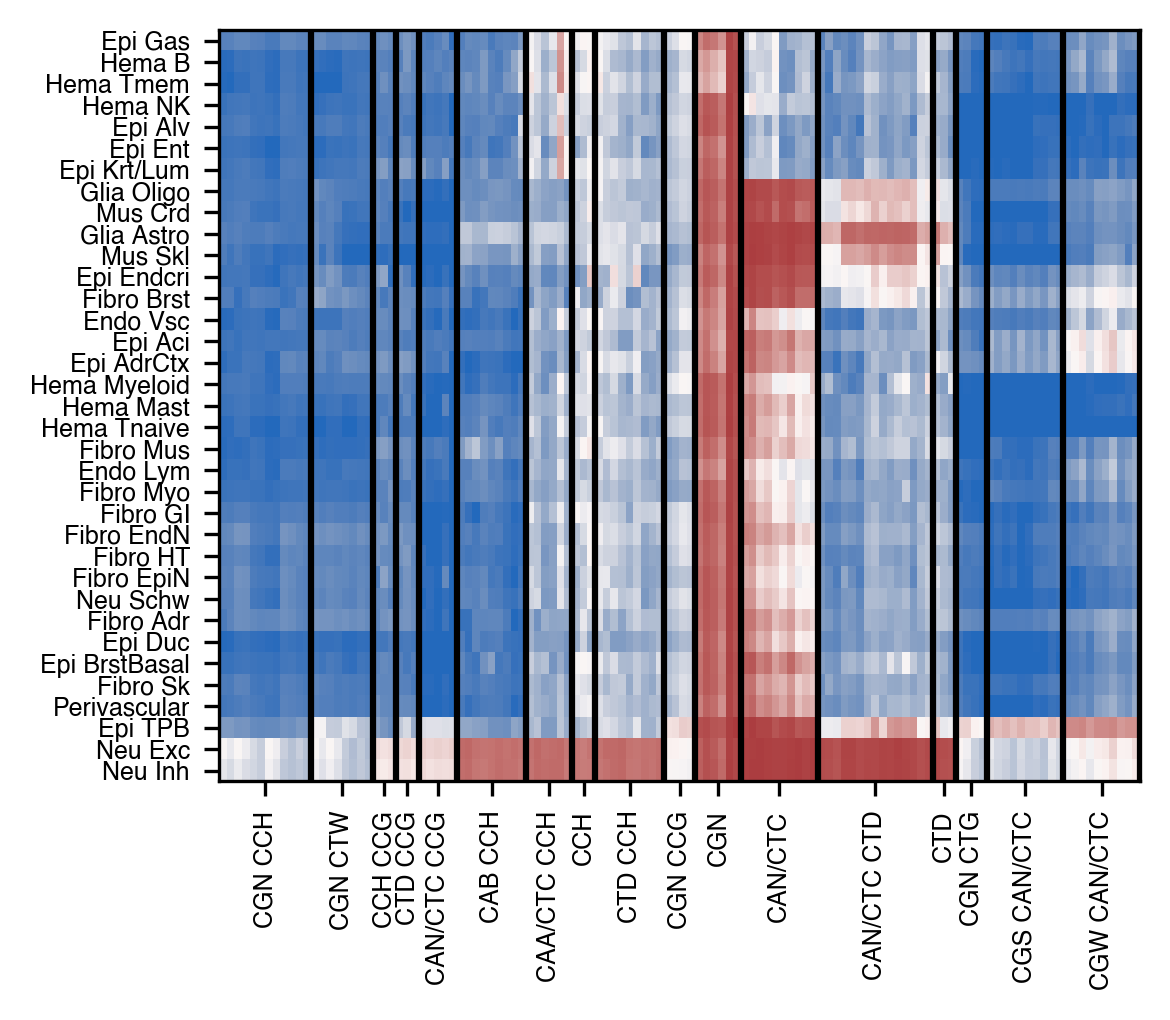

In [58]:
fig, ax = plt.subplots(figsize=(4,3.5), dpi=300)

tmp = corr.iloc[rorder]
# cg = sns.clustermap(corr, metric='cosine', row_cluster=)
ax.imshow(tmp, cmap='vlag', vmin=0, vmax=1, aspect='auto')
# ax.set_xticks([])
# xticks = np.arange(0, corr.shape[1], 1)
# ax.set_xticks(xticks)
# ax.set_xticklabels(tmp.columns[xticks], rotation=90, fontsize=6)
corder_offset = [0] + [len(xx) for xx in corder[::-1]]
corder_offset = np.cumsum(corder_offset)
ax.set_xticks((corder_offset[:-1] + corder_offset[1:] - 1) / 2)
ax.set_xticklabels(xticklabels[::-1], rotation=90, fontsize=6)
for xx in corder_offset[1:]:
    ax.plot([xx-0.5, xx-0.5], [-0.5, corr.shape[0]-0.5], 'k')
ax.set_yticks(np.arange(corr.shape[0]))
ax.set_yticklabels(tmp.index, fontsize=6)

fig.tight_layout()
fig.savefig(f'mCH_distribution/L1_mCcontext_corr_res50k_grouped.pdf', transparent=True)


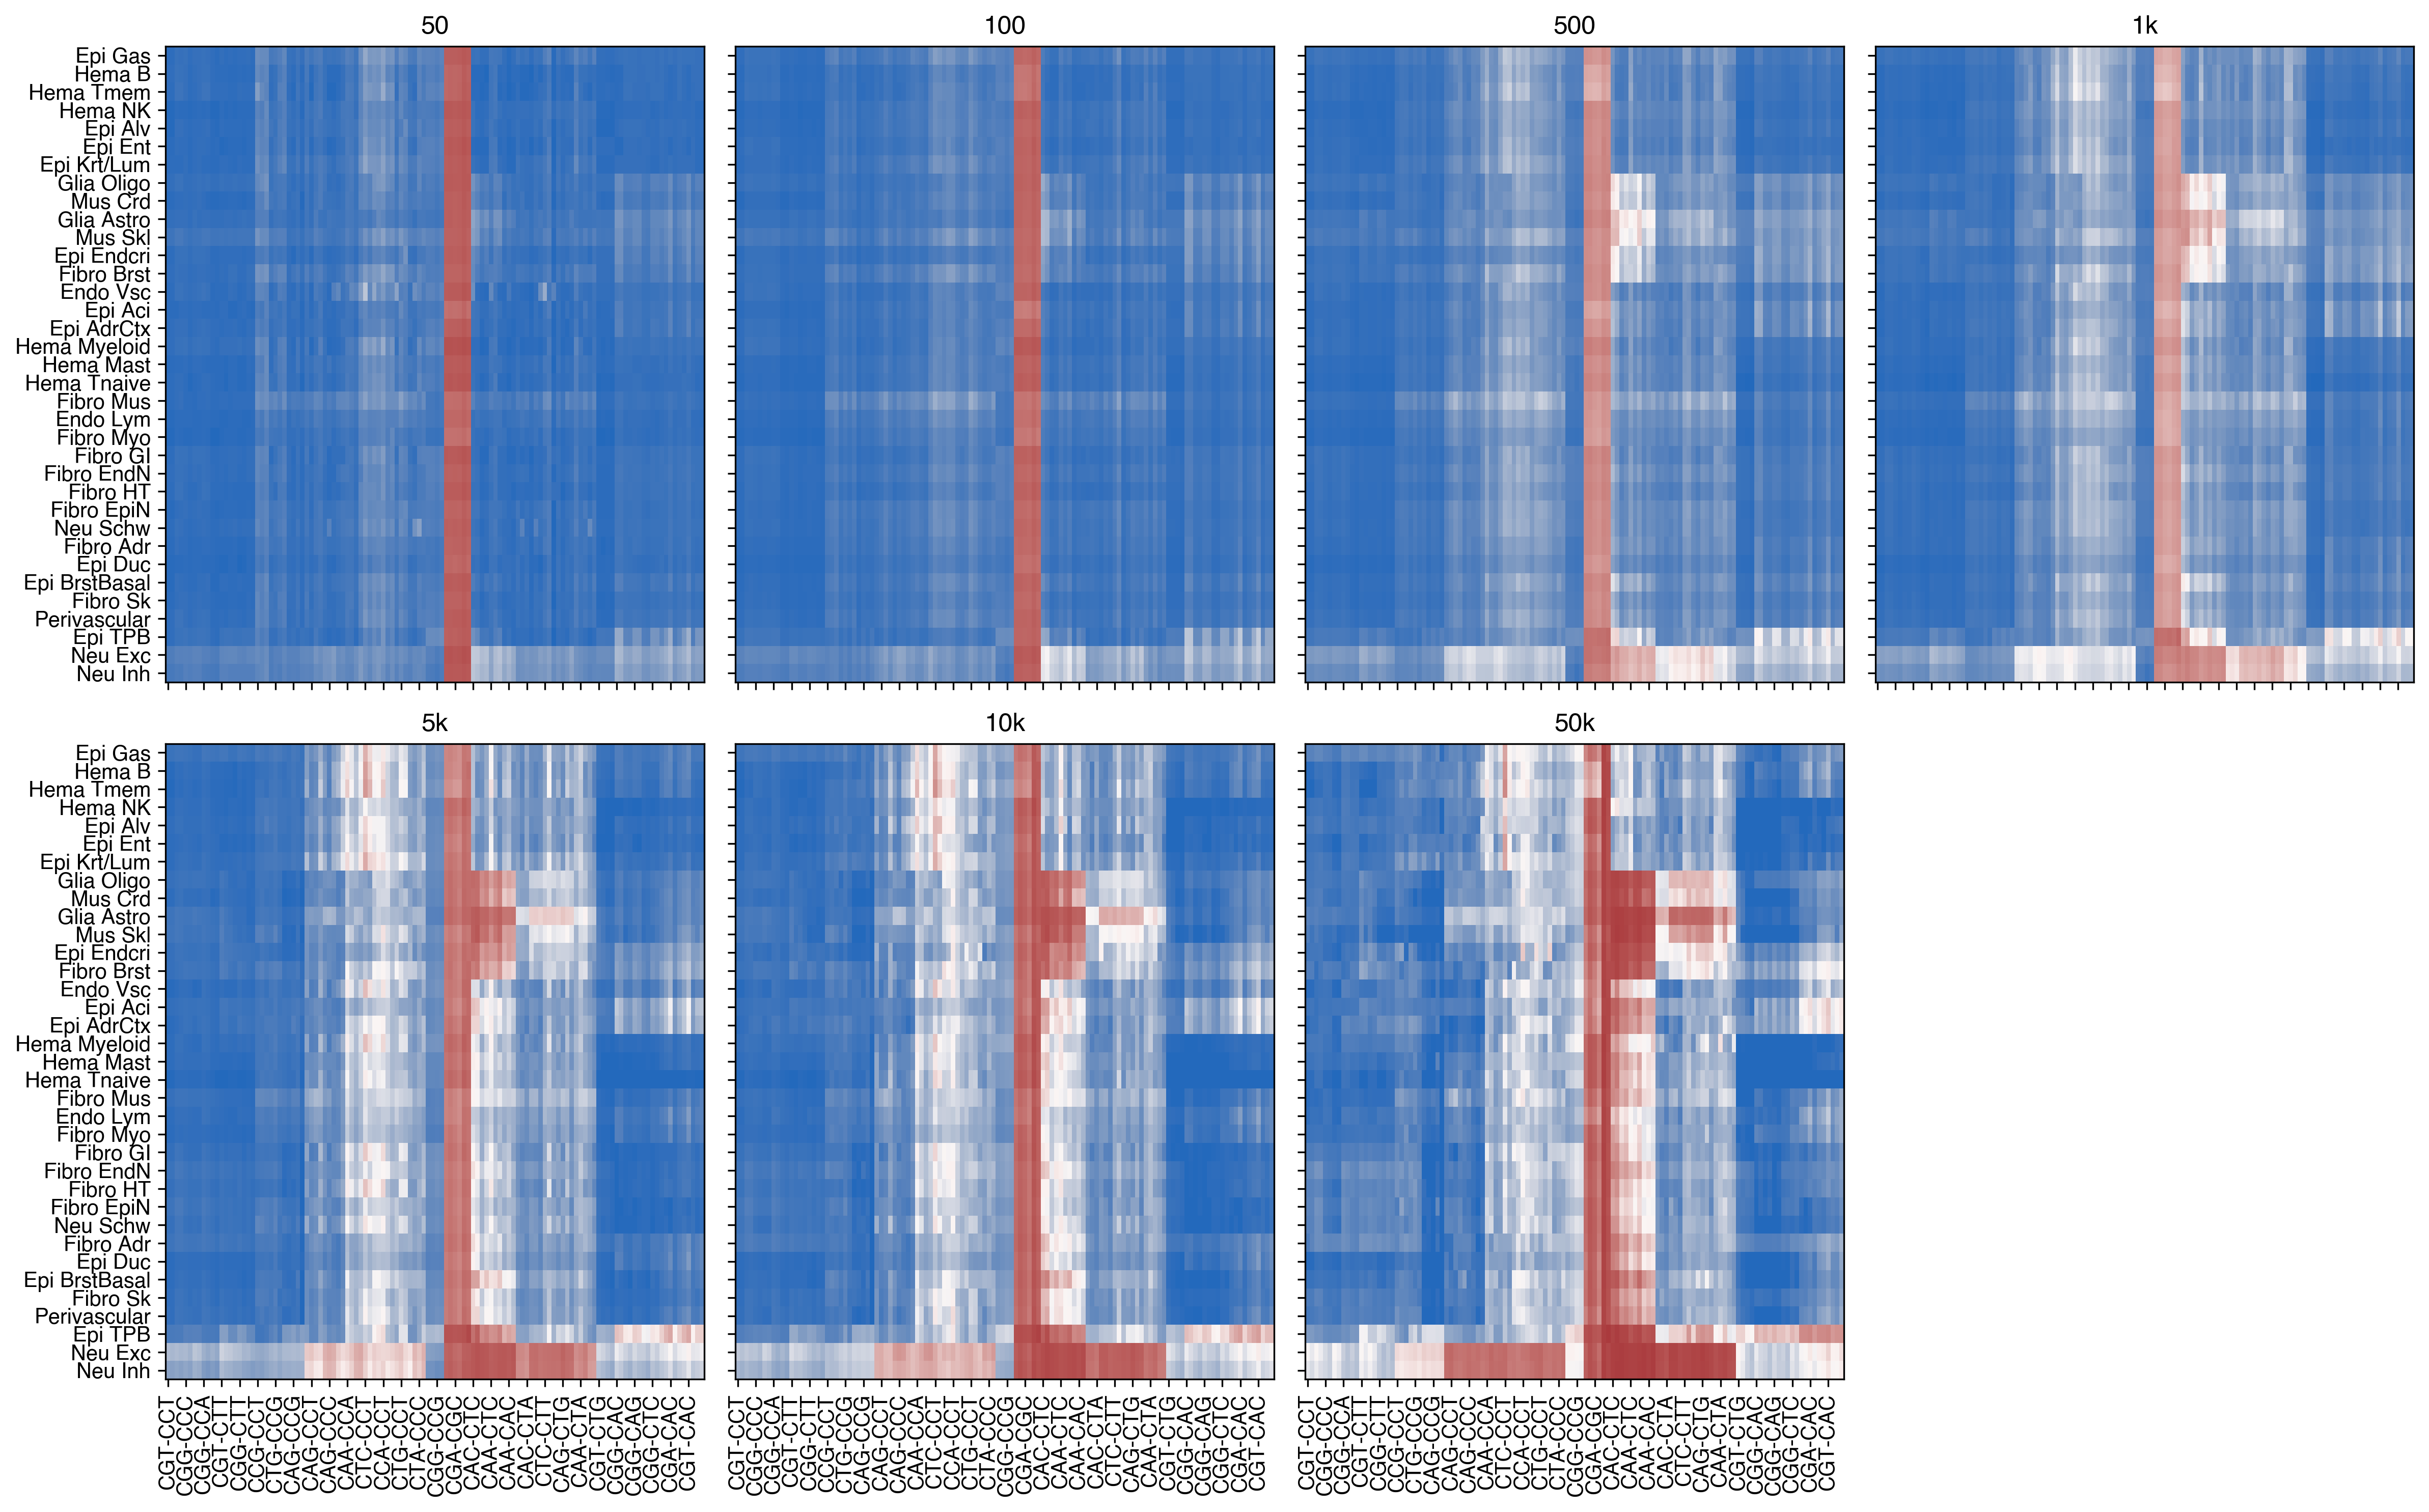

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(16,10), dpi=300, sharex='all', sharey='all')
for i,res in enumerate(reslist[1:]):
    corr = []
    for ct in L1_meta.index:
        tmp = np.load(f'mCH_distribution/multires/{ct}_corr_{num2str(res)}.npy')[reorder][:, reorder]
        tmp = np.triu(tmp).flatten()
        corr.append(tmp)

    corr = pd.DataFrame(corr, index=L1_meta['L1_abbr'], 
                        columns=[f'{xx}-{yy}' for xx in context_list for yy in context_list])
    corr = corr[np.concatenate(corder)].iloc[rorder, ::-1]
    # corr = corr.loc[:, (np.std(corr, axis=0)>0)]
    # corr = corr.iloc[rorder, corder]
    # cg = sns.clustermap(corr, metric='cosine', row_cluster=)
    ax = axes.flatten()[i]
    ax.imshow(corr, cmap='vlag', vmin=0, vmax=1, aspect='auto', rasterized=True)
    xticks = np.arange(0, corr.shape[1], 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels(corr.columns[xticks], rotation=90)
    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_yticklabels(corr.index)
    ax.set_title(num2str(res))
    # corr.to_csv(f'mCH_distribution/L1_{num2str(res)}_mCHcontext_corr.tsv.gz', sep='\t', compression='gzip')

for ax in axes.flatten()[(len(reslist)-1):]:
    ax.axis('off')
    
fig.tight_layout()
fig.savefig(f'mCH_distribution/L1_mCcontext_corr_resall.pdf', transparent=True)


In [60]:
rorder = corr.index[rorder]
rorder = rorder[rorder.isin(expr.columns)]
rorder

In [61]:
gene_list = pd.Index(['DNMT1', 'DNMT3A', 'DNMT3B', 'DNMT3L', 'TET1', 'TET2', 'TET3', 'MECP2'])
tmp = expr.loc[gene_list.map(gene2ens), rorder].T
tmp.columns = gene_list

In [62]:
from scipy.stats import ranksums
for k in gene_list:
    for i in range(4):
        xx = tmp.loc[tmp.index.map(label)==i, k]
        for j in range(i+1,5):
            yy = tmp.loc[tmp.index.map(label)==j, k]
            s, p = ranksums(xx, yy)
            if p<0.05:
                print(k, i, j, s, p)


In [63]:
from scipy.stats import ranksums
for k in gene_list:
    for i in range(5):
        xx = tmp.loc[tmp.index.map(label)==i, k]
        yy = tmp.loc[tmp.index.map(label)!=i, k]
        s, p = ranksums(xx, yy)
        if p<0.05:
            print(k, i, s, p)

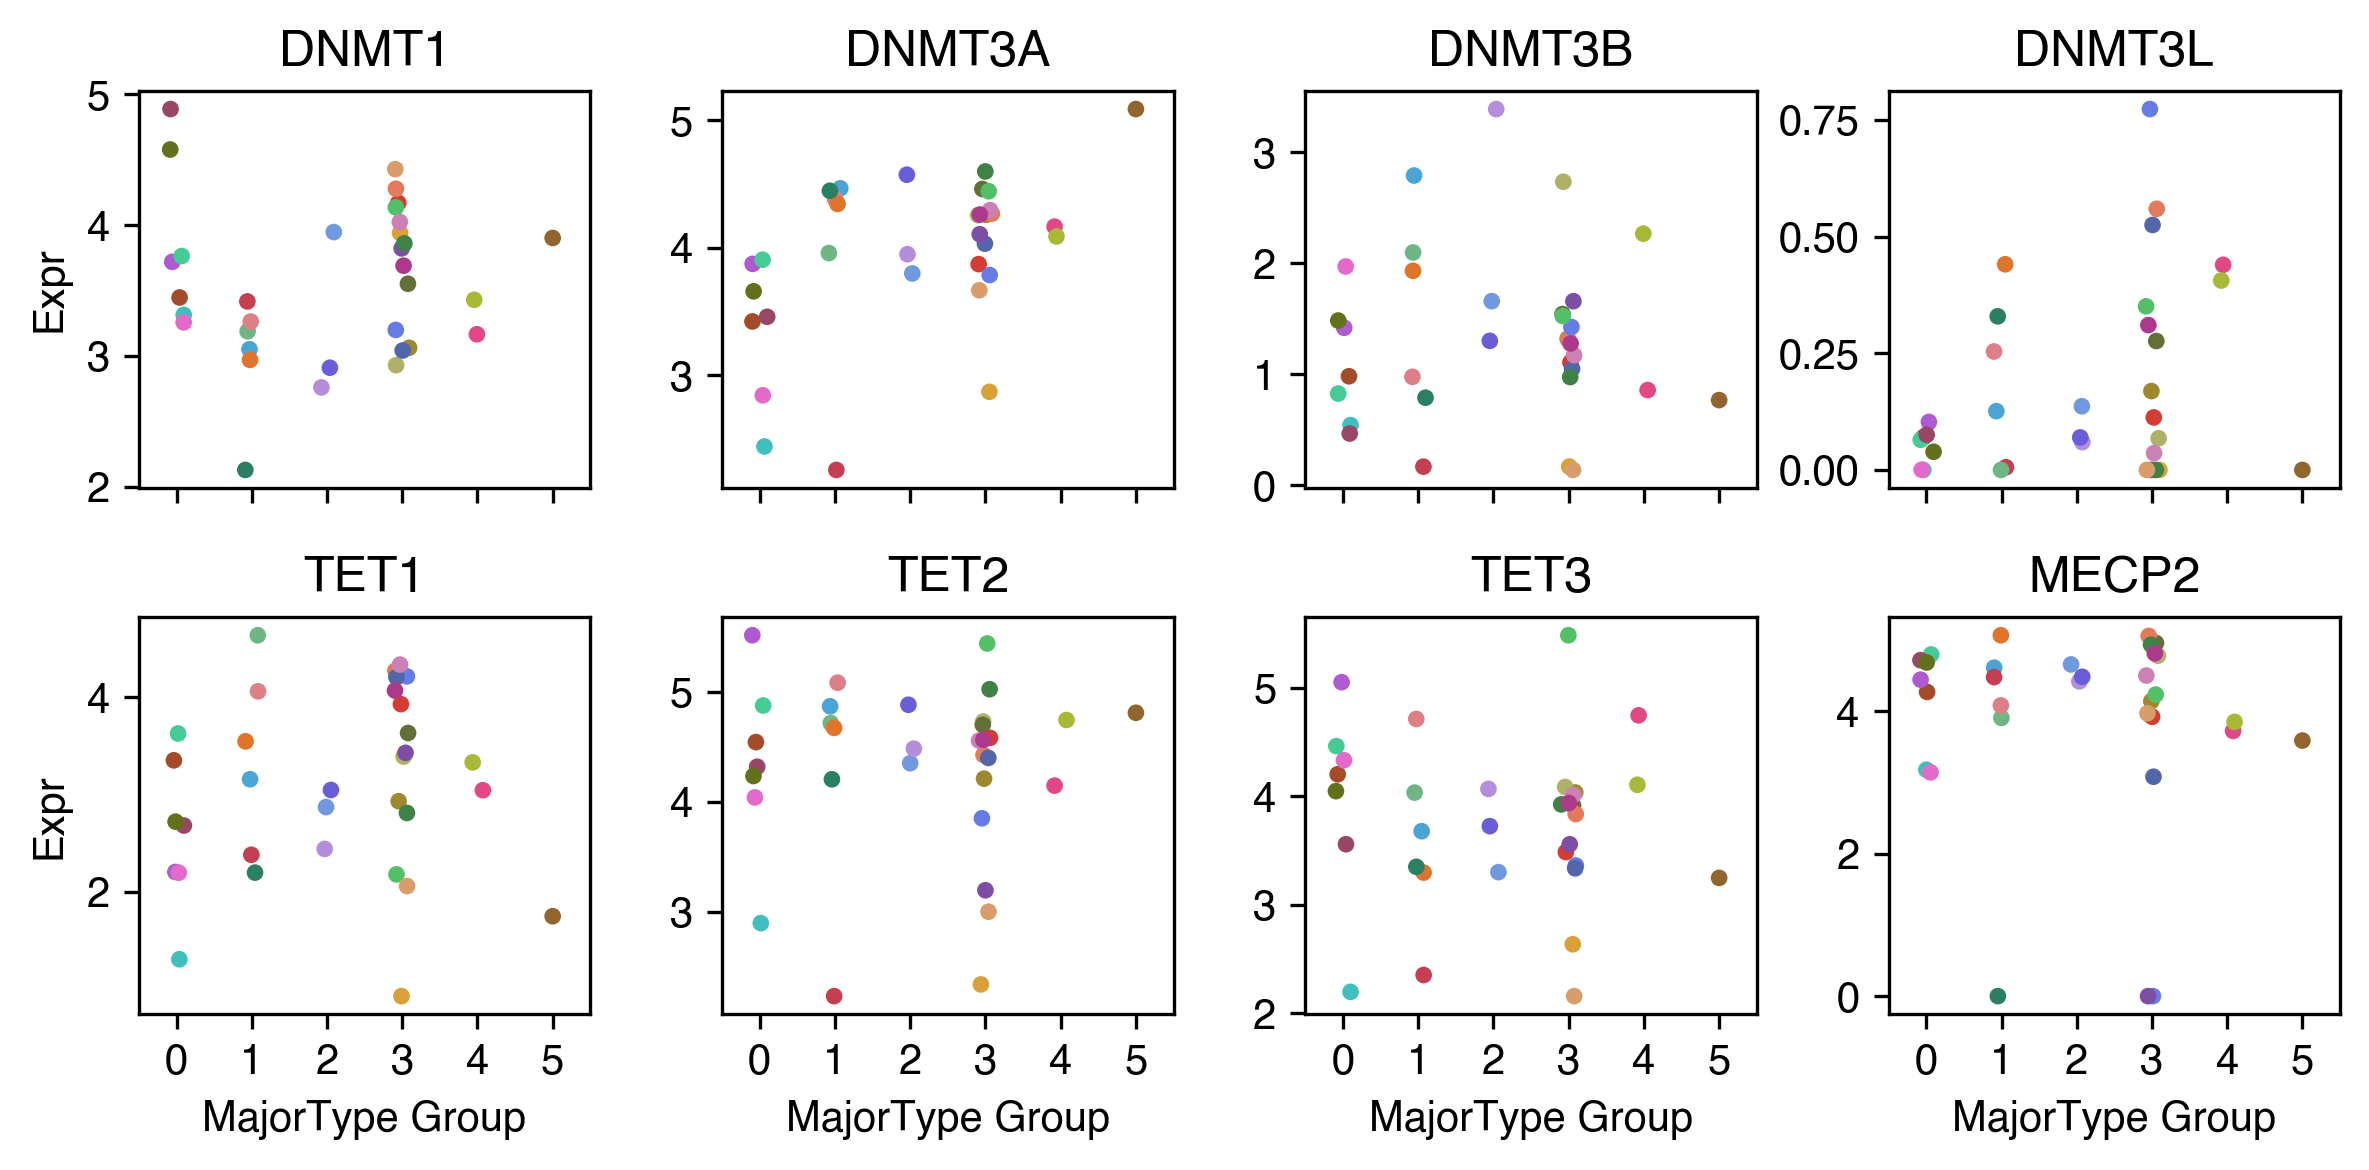

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(8,4), dpi=300, sharex='all')
for i,xx in enumerate(gene_list):
    ax = axes.flatten()[i]
    sns.stripplot(x=label.loc[label.index.isin(tmp.index)], y=tmp[xx], hue=tmp.index, 
                  s=4, edgecolor='none', palette=colors, ax=ax, legend=False)
    ax.set_title(xx)
    ax.set_xlabel('MajorType Group')
    if i%4==0:
        ax.set_ylabel('Expr')
    else:
        ax.set_ylabel('')

fig.tight_layout()
fig.savefig('mCH_distribution/mCH_group_DNMT_expr.pdf', transparent=True)


In [65]:
corr = [[np.load(f'mCH_distribution/multires/{ct.replace(" ","-").replace("/","_")}_corr_{num2str(res)}.npy').flatten() for res in reslist[1:]] for ct in L1_list]
corr = np.array(corr).reshape((len(corr), -1))
corr = pd.DataFrame(corr, index=L1_meta['L1_abbr'], columns=reslist[1:])


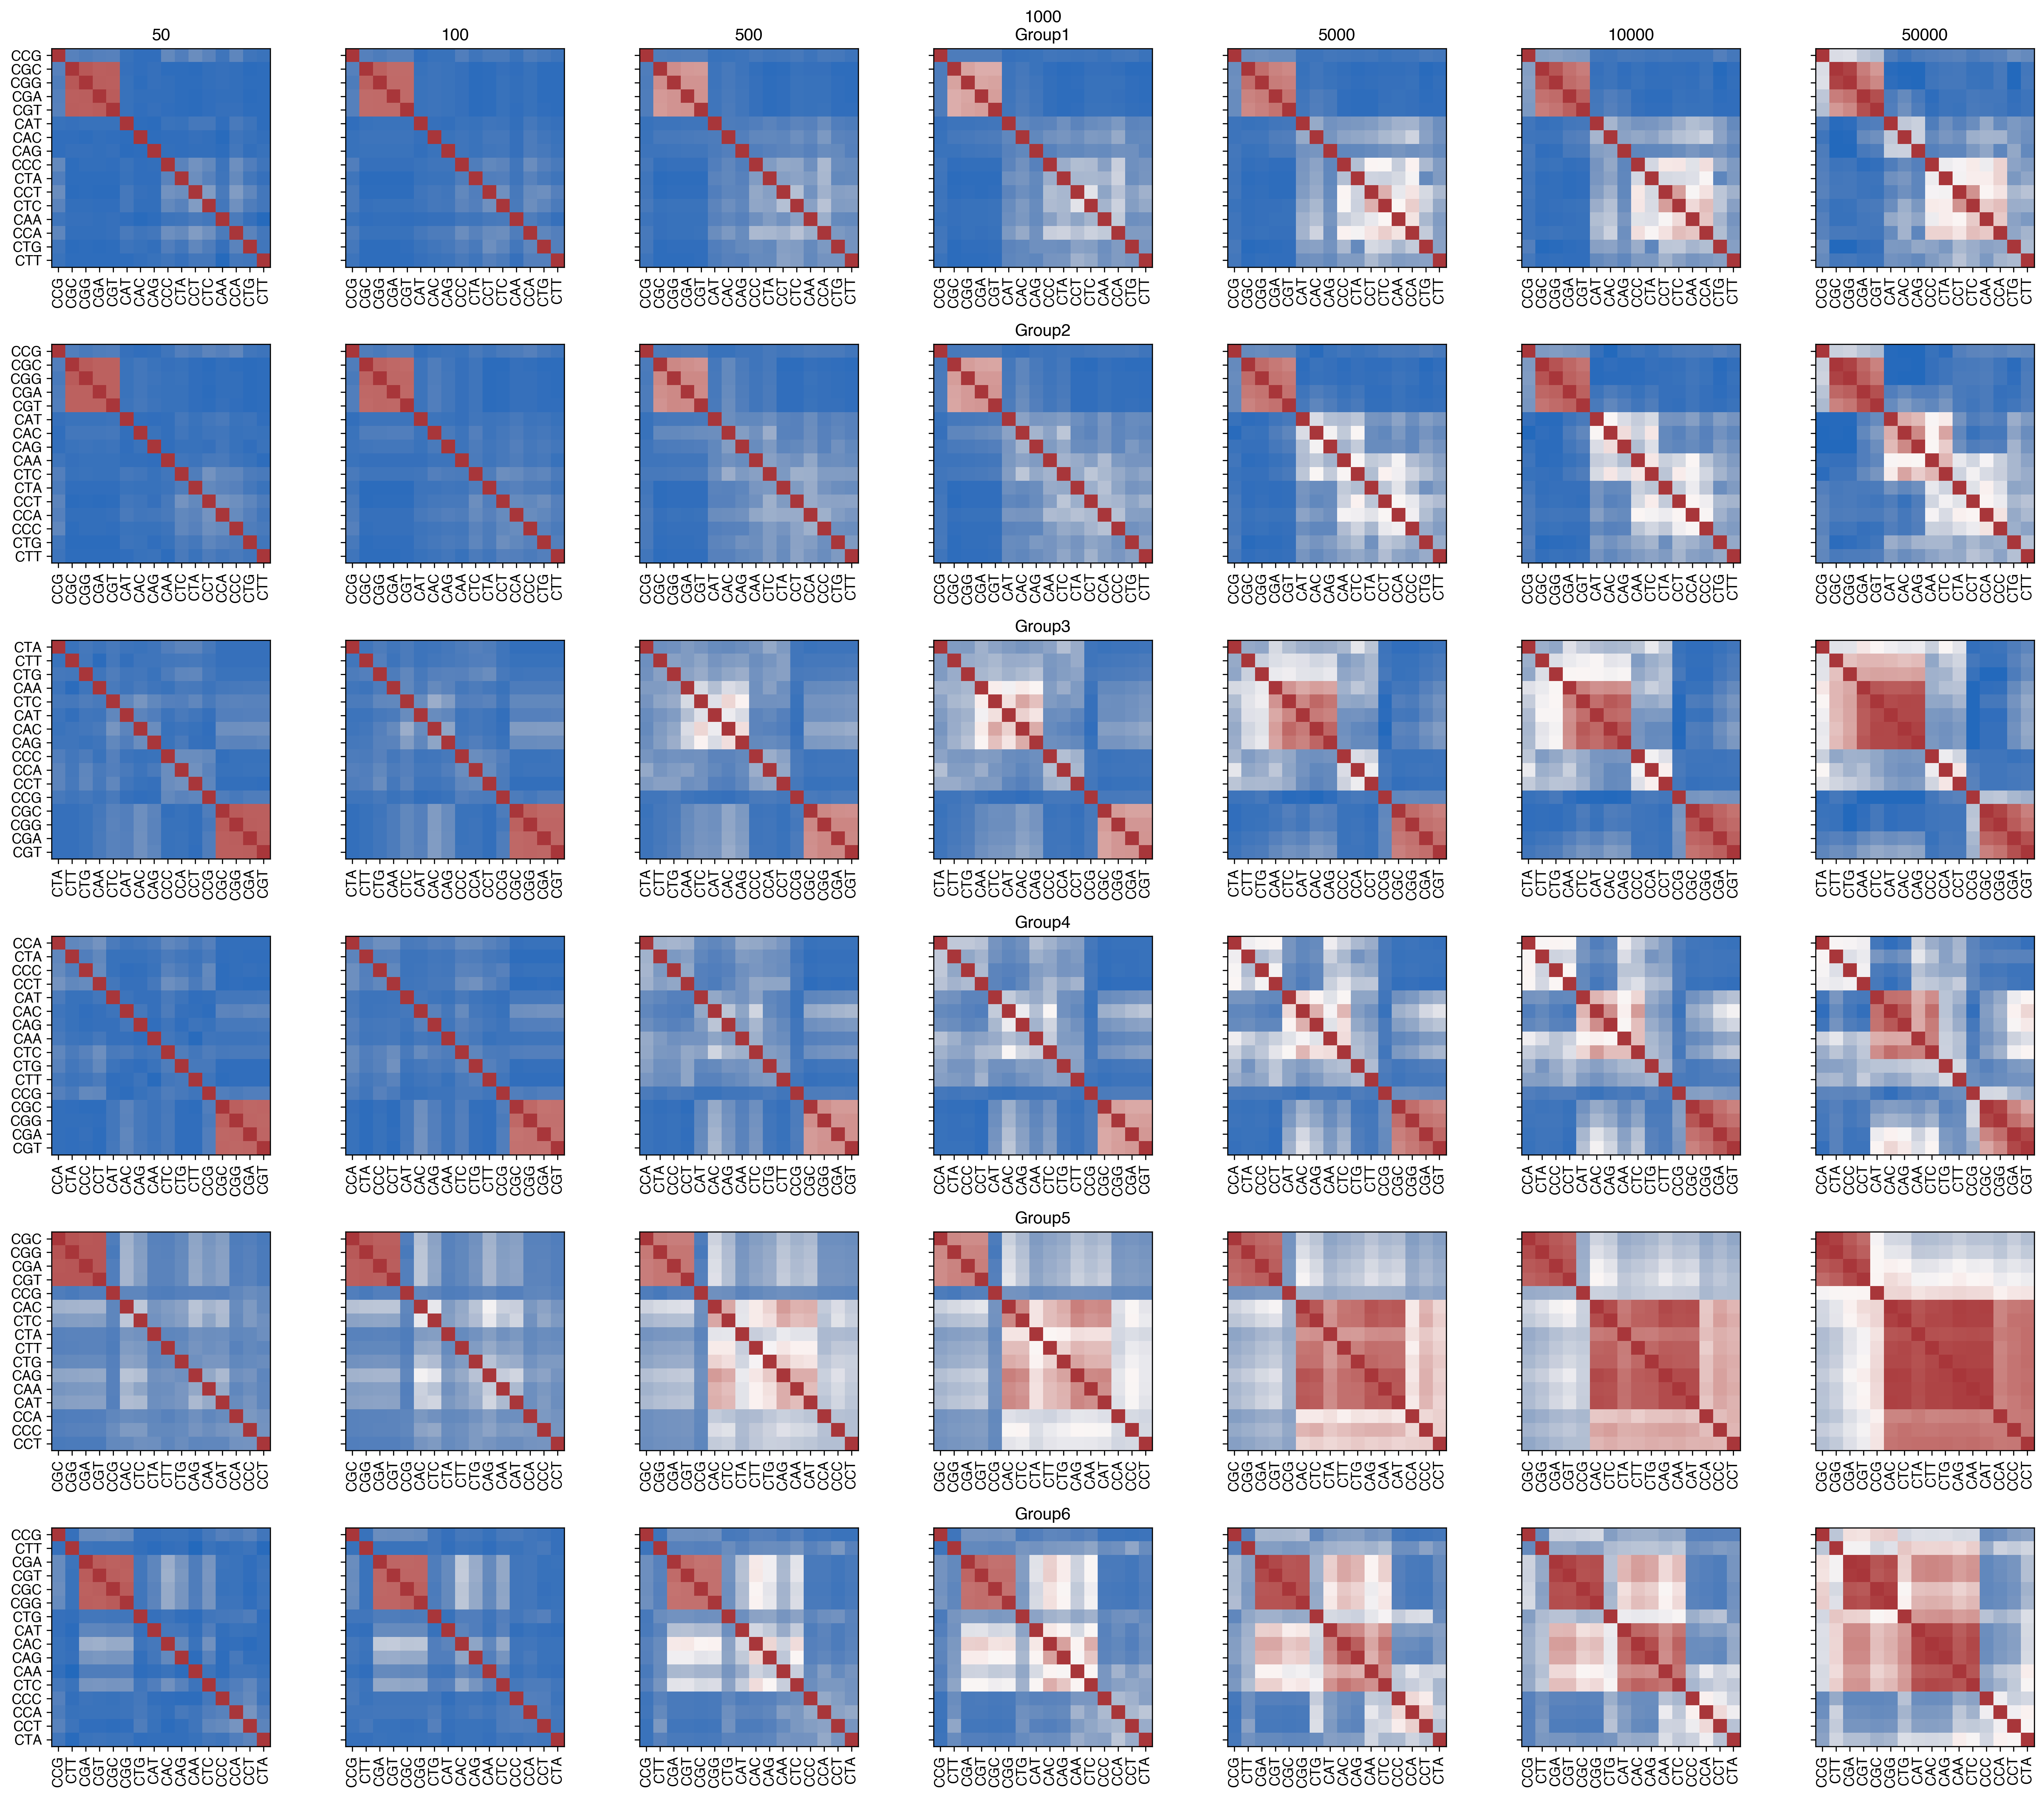

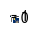

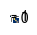

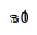

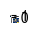

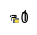

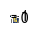

In [66]:
fig, axes = plt.subplots(6, 7, figsize=(21,18), sharex='row', sharey='row', dpi=300)
for i, ctgroup in label.index.groupby(label).items():
    corr = np.zeros((len(reslist)-1, len(context_list), len(context_list)))
    for ct in ctgroup:
        ctname = ct.replace(' ','-').replace('/','_')
        for k,res in enumerate(reslist[1:]):
            corr[k] += np.load(f'mCH_distribution/multires/{ctname}_corr_{num2str(res)}.npy')
    corr /= len(ctgroup)
    cg = sns.clustermap(corr[-1], figsize=(0.1,0.1), metric='cosine', vmin=0, vmax=1, cmap='cividis')
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    
    for k,res in enumerate(reslist[1:]):
        ax = axes[i-1,k]
        ax.imshow(corr[k][rorder][:, rorder], cmap='vlag', vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(context_list)))
        ax.set_xticklabels(context_list[rorder], rotation=90)
        ax.set_yticks(np.arange(len(context_list)))
        ax.set_yticklabels(context_list[rorder])
        if (i==1):
            if (k==3):
                ax.set_title(f'{res}\nGroup{i}')
            else:
                ax.set_title(res)
        elif (k==3):
            ax.set_title(f'Group{i}')

fig.tight_layout()
fig.savefig(f'mCH_distribution/L1group_mCcontext_corr.pdf', transparent=True)
